# Stage 05 v3 — Locomizer two-time footfall change + FMI station PM₂.₅

## Purpose

This notebook combines:

- **Locomizer H3 footfall / presence data**, and
- **historical FMI / municipal PM₂.₅ station observations** prepared in Stage 00.

It replaces the previous raster placeholders with the actual cleaned station-observation outputs.

## Important interpretation

The PM₂.₅ data used here are **point observations from monitoring stations**, not a spatially continuous ENFUSER raster.

Therefore this notebook uses PM₂.₅ primarily to:

1. characterize environmental conditions at Time A and Time B;
2. compare the regional station network between the two times;
3. assess whether footfall increased, decreased, or stayed stable while regional PM₂.₅ changed.

It does **not** assign a unique PM₂.₅ concentration to every H3 cell.

That spatial step should only be added later with a defensible interpolation method or archived ENFUSER gridded data.


## 1. Imports and project paths

In [1]:
from pathlib import Path

import h3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# -------------------------------------------------------------------
# Project paths
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/scratch/project_2010417")

LOCOMIZER_DERIVED_DIR = (
    PROJECT_ROOT
    / "paper3"
    / "locomizer"
    / "derived"
)

FOOTFALL_PARQUET = (
    LOCOMIZER_DERIVED_DIR
    / "helsinki_footfall_hourly_exploratory_2023-06-10_20.parquet"
)

BOUNDARY_CACHE = (
    LOCOMIZER_DERIVED_DIR
    / "helsinki_metropolitan_area_boundary.gpkg"
)

PM25_DERIVED_DIR = (
    PROJECT_ROOT
    / "paper3"
    / "airqualityontario22-25"
    / "HMA_pm25"
    / "derived"
)

PM25_STATION_PARQUET = (
    PM25_DERIVED_DIR
    / "hma_pm25_station_hour_clean.parquet"
)

PM25_REGIONAL_CSV = (
    PM25_DERIVED_DIR
    / "hma_pm25_regional_hourly.csv"
)

PM25_CANDIDATE_PAIRS_CSV = (
    PM25_DERIVED_DIR
    / "hma_pm25_same_hour_candidate_pairs.csv"
)

OUTPUT_DIR = Path("../outputs/v3/05_locomizer_station_pm25")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Footfall:", FOOTFALL_PARQUET)
print("PM2.5 station data:", PM25_STATION_PARQUET)
print("PM2.5 regional summary:", PM25_REGIONAL_CSV)
print("Output:", OUTPUT_DIR.resolve())


Footfall: /scratch/project_2010417/paper3/locomizer/derived/helsinki_footfall_hourly_exploratory_2023-06-10_20.parquet
PM2.5 station data: /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_station_hour_clean.parquet
PM2.5 regional summary: /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_regional_hourly.csv
Output: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/05_locomizer_station_pm25


## 2. Select the two comparison times

The current proof-of-concept comparison remains:

- **Time A:** 17 June 2023 at 12:00 local time
- **Time B:** 18 June 2023 at 12:00 local time

Stage 00 showed that PM₂.₅ at these two times may not represent a strong high-vs-low contrast. This notebook keeps them for continuity, but later you can replace them with a stronger pair from the Stage 00 candidate-pairs table.


In [2]:
TIME_A = pd.Timestamp("2023-06-17 12:00")
TIME_B = pd.Timestamp("2023-06-18 12:00")

TIME_A_DATE = TIME_A.normalize()
TIME_B_DATE = TIME_B.normalize()

TIME_A_HOUR = TIME_A.hour
TIME_B_HOUR = TIME_B.hour

print("Time A:", TIME_A)
print("Time B:", TIME_B)


Time A: 2023-06-17 12:00:00
Time B: 2023-06-18 12:00:00


## 3. Load Locomizer footfall

In [3]:
if not FOOTFALL_PARQUET.exists():
    raise FileNotFoundError(
        f"{FOOTFALL_PARQUET} was not found. "
        "Run the Locomizer exploration notebook first."
    )

footfall = pd.read_parquet(FOOTFALL_PARQUET)

required = {
    "CODE",
    "date",
    "TIME_INTERVAL",
    "NUMBER_OF_USERS",
}

missing = required.difference(footfall.columns)

if missing:
    raise ValueError(
        f"Missing expected Locomizer columns: {sorted(missing)}"
    )

footfall["date"] = pd.to_datetime(footfall["date"])

print("Rows:", len(footfall))
print("Dates:", footfall["date"].min().date(), "to", footfall["date"].max().date())
print("H3 cells:", footfall["CODE"].nunique())


Rows: 1420486
Dates: 2023-06-10 to 2023-06-20
H3 cells: 17312


## 4. Load HMA boundary

In [4]:
if not BOUNDARY_CACHE.exists():
    raise FileNotFoundError(
        f"{BOUNDARY_CACHE} was not found."
    )

hma_boundary = gpd.read_file(
    BOUNDARY_CACHE
).to_crs("EPSG:4326")

hma_boundary


,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,24.782803,59.922486,25.254512,60.29785,167666314,relation,34914,60.16662,24.943541,boundary,administrative,15,0.797091,city,Helsinki,"Helsinki, Helsinki sub-region, Uusimaa, Mainla...","POLYGON ((25.19026 60.28567, 25.19187 60.28468..."


## 5. Load cleaned FMI station PM₂.₅ data

In [5]:
if not PM25_STATION_PARQUET.exists():
    raise FileNotFoundError(
        f"{PM25_STATION_PARQUET} was not found. "
        "Run 00_stage_fmi_station_pm25_prepare.ipynb first."
    )

pm25_station = pd.read_parquet(
    PM25_STATION_PARQUET
)

pm25_station["datetime_local"] = pd.to_datetime(
    pm25_station["datetime_local"]
)

print("Station-hour rows:", len(pm25_station))
print("Stations:", pm25_station["station"].nunique())
print(
    "Time range:",
    pm25_station["datetime_local"].min(),
    "to",
    pm25_station["datetime_local"].max(),
)

display(pm25_station.head())


Station-hour rows: 480
Stations: 10
Time range: 2023-06-17 07:00:00 to 2023-06-19 06:00:00


,station,datetime_local,datetime_helsinki,datetime_utc,pm25_ugm3,air_quality_index,n_source_rows,source_files
0,Espoo Leppävaara Läkkisepänkuja,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,17.6,2.0,1,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
1,Espoo Luukki,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,13.5,2.0,1,Espoo Luukki_ 17.6.2023 - 19.6.2023_c26d6684-9...
2,Helsinki Kallio 2,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,12.9,2.0,1,Helsinki Kallio 2_ 17.6.2023 - 19.6.2023_1e801...
3,Helsinki Mannerheimintie,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,21.3,3.0,1,Helsinki Mannerheimintie_ 17.6.2023 - 19.6.202...
4,Helsinki Mäkelänkatu,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,21.4,3.0,1,Helsinki Mäkelänkatu_ 17.6.2023 - 19.6.2023_...


## 6. Load regional hourly PM₂.₅ summary

In [6]:
if not PM25_REGIONAL_CSV.exists():
    raise FileNotFoundError(
        f"{PM25_REGIONAL_CSV} was not found. "
        "Run Stage 00 first."
    )

regional_pm25 = pd.read_csv(
    PM25_REGIONAL_CSV,
    parse_dates=["datetime_local"],
)

display(regional_pm25.head())


,datetime_local,pm25_mean,pm25_median,pm25_min,pm25_max,pm25_std,n_stations,date,hour
0,2023-06-17 07:00:00,16.73,16.65,12.9,21.4,2.980324,10,2023-06-17,7
1,2023-06-17 08:00:00,15.28,14.45,13.0,24.3,3.285253,10,2023-06-17,8
2,2023-06-17 09:00:00,12.25,11.90,10.1,16.1,1.882227,10,2023-06-17,9
3,2023-06-17 10:00:00,9.93,9.80,7.3,14.4,2.029806,10,2023-06-17,10
4,2023-06-17 11:00:00,9.57,9.30,7.9,12.1,1.609727,10,2023-06-17,11


## 7. Extract Time A and Time B footfall

Only H3 cells observed at **both** timestamps are retained.

This avoids treating a missing Locomizer observation as zero activity.


In [7]:
time_a = footfall.loc[
    (footfall["date"] == TIME_A_DATE)
    & (footfall["TIME_INTERVAL"] == TIME_A_HOUR)
].copy()

time_b = footfall.loc[
    (footfall["date"] == TIME_B_DATE)
    & (footfall["TIME_INTERVAL"] == TIME_B_HOUR)
].copy()

print("Time A rows:", len(time_a))
print("Time B rows:", len(time_b))

if time_a.empty:
    raise ValueError("No Locomizer observations found for Time A.")

if time_b.empty:
    raise ValueError("No Locomizer observations found for Time B.")


Time A rows: 6883
Time B rows: 6338


## 8. Create H3 polygons and merge the two footfall snapshots

In [8]:
def h3_to_polygon(cell):
    boundary = h3.cell_to_boundary(str(cell))
    return Polygon(
        [(lon, lat) for lat, lon in boundary]
    )

a = time_a[
    ["CODE", "NUMBER_OF_USERS"]
].rename(
    columns={"NUMBER_OF_USERS": "footfall_A"}
)

b = time_b[
    ["CODE", "NUMBER_OF_USERS"]
].rename(
    columns={"NUMBER_OF_USERS": "footfall_B"}
)

comparison = a.merge(
    b,
    on="CODE",
    how="inner",
)

comparison["geometry"] = comparison["CODE"].map(
    h3_to_polygon
)

comparison_gdf = gpd.GeoDataFrame(
    comparison,
    geometry="geometry",
    crs="EPSG:4326",
)

print("Cells observed at both times:", len(comparison_gdf))
display(comparison_gdf.head())


Cells observed at both times: 4873


,CODE,footfall_A,footfall_B,geometry
0,8a08996d4c67fff,1,3,"POLYGON ((24.81277 60.26544, 24.81357 60.265, ..."
1,8a1126d3381ffff,5,5,"POLYGON ((24.93321 60.16945, 24.93401 60.16901..."
2,8a1126d0e277fff,1,1,"POLYGON ((25.03799 60.23481, 25.03879 60.23437..."
3,8a08996a8797fff,3,3,"POLYGON ((24.71006 60.23679, 24.71086 60.23635..."
4,8a1126d2922ffff,2,6,"POLYGON ((24.9754 60.28421, 24.9762 60.28377, ..."


## 9. Calculate H3-level footfall change

In [9]:
comparison_gdf["delta_footfall"] = (
    comparison_gdf["footfall_B"]
    - comparison_gdf["footfall_A"]
)

comparison_gdf["pct_change_footfall"] = np.where(
    comparison_gdf["footfall_A"] > 0,
    100
    * comparison_gdf["delta_footfall"]
    / comparison_gdf["footfall_A"],
    np.nan,
)

display(
    comparison_gdf[
        [
            "CODE",
            "footfall_A",
            "footfall_B",
            "delta_footfall",
            "pct_change_footfall",
        ]
    ].head()
)


,CODE,footfall_A,footfall_B,delta_footfall,pct_change_footfall
0,8a08996d4c67fff,1,3,2,200.0
1,8a1126d3381ffff,5,5,0,0.0
2,8a1126d0e277fff,1,1,0,0.0
3,8a08996a8797fff,3,3,0,0.0
4,8a1126d2922ffff,2,6,4,200.0


## 10. Extract station PM₂.₅ observations at Time A and Time B

In [10]:
station_two_time = pm25_station.loc[
    pm25_station["datetime_local"].isin(
        [TIME_A, TIME_B]
    )
].copy()

station_two_time["time_label"] = np.where(
    station_two_time["datetime_local"] == TIME_A,
    "Time A",
    "Time B",
)

print(
    "Stations at Time A:",
    station_two_time.loc[
        station_two_time["datetime_local"] == TIME_A,
        "station",
    ].nunique(),
)

print(
    "Stations at Time B:",
    station_two_time.loc[
        station_two_time["datetime_local"] == TIME_B,
        "station",
    ].nunique(),
)

display(
    station_two_time[
        [
            "time_label",
            "station",
            "datetime_local",
            "pm25_ugm3",
        ]
    ].sort_values(
        ["station", "datetime_local"]
    )
)


Stations at Time A: 10
Stations at Time B: 10


,time_label,station,datetime_local,pm25_ugm3
50,Time A,Espoo Leppävaara Läkkisepänkuja,2023-06-17 12:00:00,9.9
290,Time B,Espoo Leppävaara Läkkisepänkuja,2023-06-18 12:00:00,7.2
51,Time A,Espoo Luukki,2023-06-17 12:00:00,10.1
291,Time B,Espoo Luukki,2023-06-18 12:00:00,6.8
52,Time A,Helsinki Kallio 2,2023-06-17 12:00:00,9.7
292,Time B,Helsinki Kallio 2,2023-06-18 12:00:00,7.0
53,Time A,Helsinki Mannerheimintie,2023-06-17 12:00:00,11.5
293,Time B,Helsinki Mannerheimintie,2023-06-18 12:00:00,10.0
54,Time A,Helsinki Mäkelänkatu,2023-06-17 12:00:00,8.9
294,Time B,Helsinki Mäkelänkatu,2023-06-18 12:00:00,6.5


## 11. Regional PM₂.₅ comparison for the two times

In [11]:
regional_two_time = regional_pm25.loc[
    regional_pm25["datetime_local"].isin(
        [TIME_A, TIME_B]
    )
].copy()

if len(regional_two_time) != 2:
    print(
        "Warning: expected two regional PM2.5 rows, found",
        len(regional_two_time),
    )

display(regional_two_time)

regional_lookup = (
    regional_two_time
    .set_index("datetime_local")
)

pm25_A_median = regional_lookup.loc[
    TIME_A,
    "pm25_median",
]

pm25_B_median = regional_lookup.loc[
    TIME_B,
    "pm25_median",
]

pm25_A_mean = regional_lookup.loc[
    TIME_A,
    "pm25_mean",
]

pm25_B_mean = regional_lookup.loc[
    TIME_B,
    "pm25_mean",
]

delta_pm25_median = (
    pm25_B_median - pm25_A_median
)

delta_pm25_mean = (
    pm25_B_mean - pm25_A_mean
)

print(f"Regional median PM2.5, Time A: {pm25_A_median:.2f} µg/m³")
print(f"Regional median PM2.5, Time B: {pm25_B_median:.2f} µg/m³")
print(f"Δ regional median PM2.5: {delta_pm25_median:.2f} µg/m³")

print()
print(f"Regional mean PM2.5, Time A: {pm25_A_mean:.2f} µg/m³")
print(f"Regional mean PM2.5, Time B: {pm25_B_mean:.2f} µg/m³")
print(f"Δ regional mean PM2.5: {delta_pm25_mean:.2f} µg/m³")


,datetime_local,pm25_mean,pm25_median,pm25_min,pm25_max,pm25_std,n_stations,date,hour
5,2023-06-17 12:00:00,9.65,9.60,8.3,11.5,0.874643,10,2023-06-17,12
29,2023-06-18 12:00:00,7.10,6.75,5.6,10.0,1.498888,10,2023-06-18,12


Regional median PM2.5, Time A: 9.60 µg/m³
Regional median PM2.5, Time B: 6.75 µg/m³
Δ regional median PM2.5: -2.85 µg/m³

Regional mean PM2.5, Time A: 9.65 µg/m³
Regional mean PM2.5, Time B: 7.10 µg/m³
Δ regional mean PM2.5: -2.55 µg/m³


## 12. Station-by-station PM₂.₅ change

This checks whether the regional change is consistent across monitoring stations or driven by a small subset.


In [12]:
station_wide = (
    station_two_time
    .pivot_table(
        index="station",
        columns="time_label",
        values="pm25_ugm3",
        aggfunc="mean",
    )
    .reset_index()
)

if {"Time A", "Time B"}.issubset(
    station_wide.columns
):
    station_wide["delta_pm25"] = (
        station_wide["Time B"]
        - station_wide["Time A"]
    )

    station_wide["pct_change_pm25"] = np.where(
        station_wide["Time A"] > 0,
        100
        * station_wide["delta_pm25"]
        / station_wide["Time A"],
        np.nan,
    )

display(
    station_wide.sort_values(
        "delta_pm25"
    )
)


time_label,station,Time A,Time B,delta_pm25,pct_change_pm25
5,Helsinki Tapanila,9.5,5.7,-3.8,-40.000000
8,Vantaa Jätevoimala,9.4,6.0,-3.4,-36.170213
1,Espoo Luukki,10.1,6.8,-3.3,-32.673267
6,Helsinki Vartiokylä Huivipolku,8.3,5.6,-2.7,-32.530120
0,Espoo Leppävaara Läkkisepänkuja,9.9,7.2,-2.7,-27.272727
2,Helsinki Kallio 2,9.7,7.0,-2.7,-27.835052
4,Helsinki Mäkelänkatu,8.9,6.5,-2.4,-26.966292
9,Vantaa Tikkurila Neilikkatie,9.0,6.7,-2.3,-25.555556
3,Helsinki Mannerheimintie,11.5,10.0,-1.5,-13.043478
7,Kauniainen Kauniaistentie,10.2,9.5,-0.7,-6.862745


## 13. Plot station PM₂.₅ at Time A and Time B

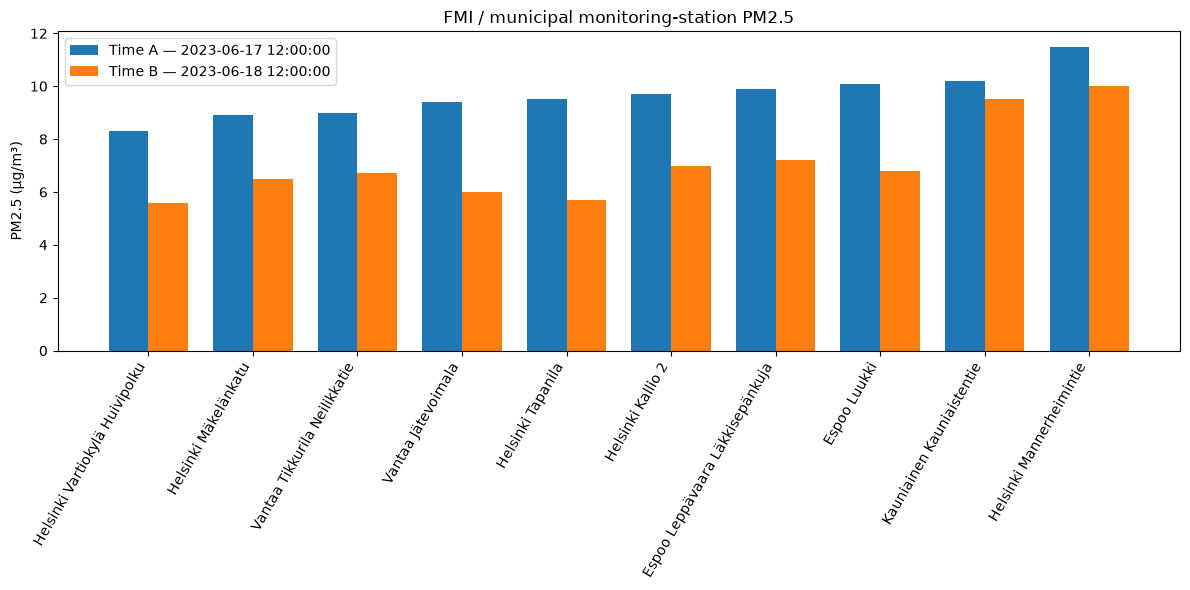

In [13]:
plot_station = station_wide.dropna(
    subset=["Time A", "Time B"]
).copy()

plot_station = plot_station.sort_values(
    "Time A"
)

x = np.arange(len(plot_station))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width / 2,
    plot_station["Time A"],
    width,
    label=f"Time A — {TIME_A}",
)

ax.bar(
    x + width / 2,
    plot_station["Time B"],
    width,
    label=f"Time B — {TIME_B}",
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_station["station"],
    rotation=60,
    ha="right",
)

ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title(
    "FMI / municipal monitoring-station PM2.5"
)
ax.legend()

plt.tight_layout()
plt.show()


## 14. Plot regional PM₂.₅ through the available period

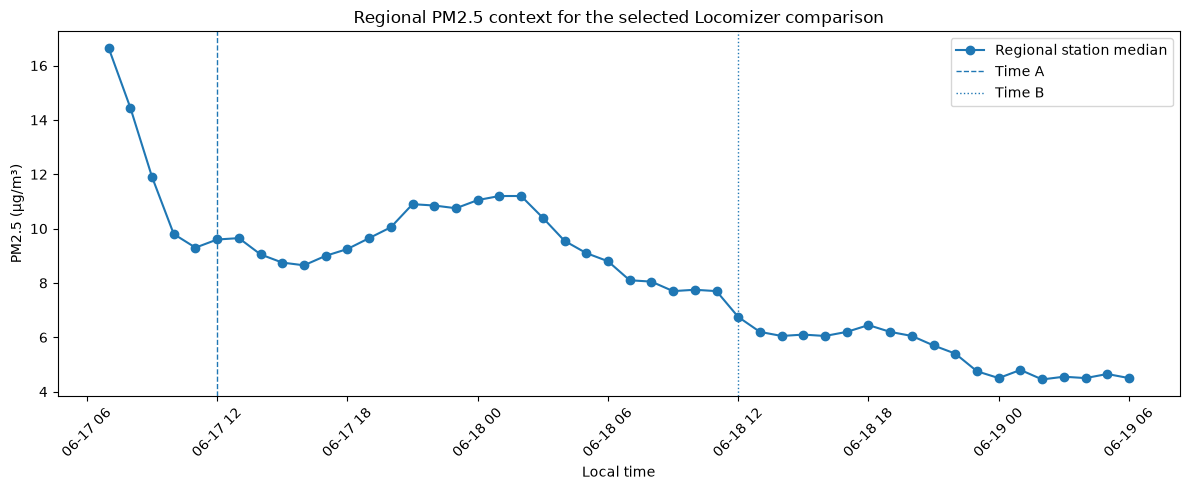

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    regional_pm25["datetime_local"],
    regional_pm25["pm25_median"],
    marker="o",
    label="Regional station median",
)

ax.axvline(
    TIME_A,
    linestyle="--",
    linewidth=1,
    label="Time A",
)

ax.axvline(
    TIME_B,
    linestyle=":",
    linewidth=1,
    label="Time B",
)

ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("Local time")
ax.set_title(
    "Regional PM2.5 context for the selected Locomizer comparison"
)

ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 15. Map footfall at Time A

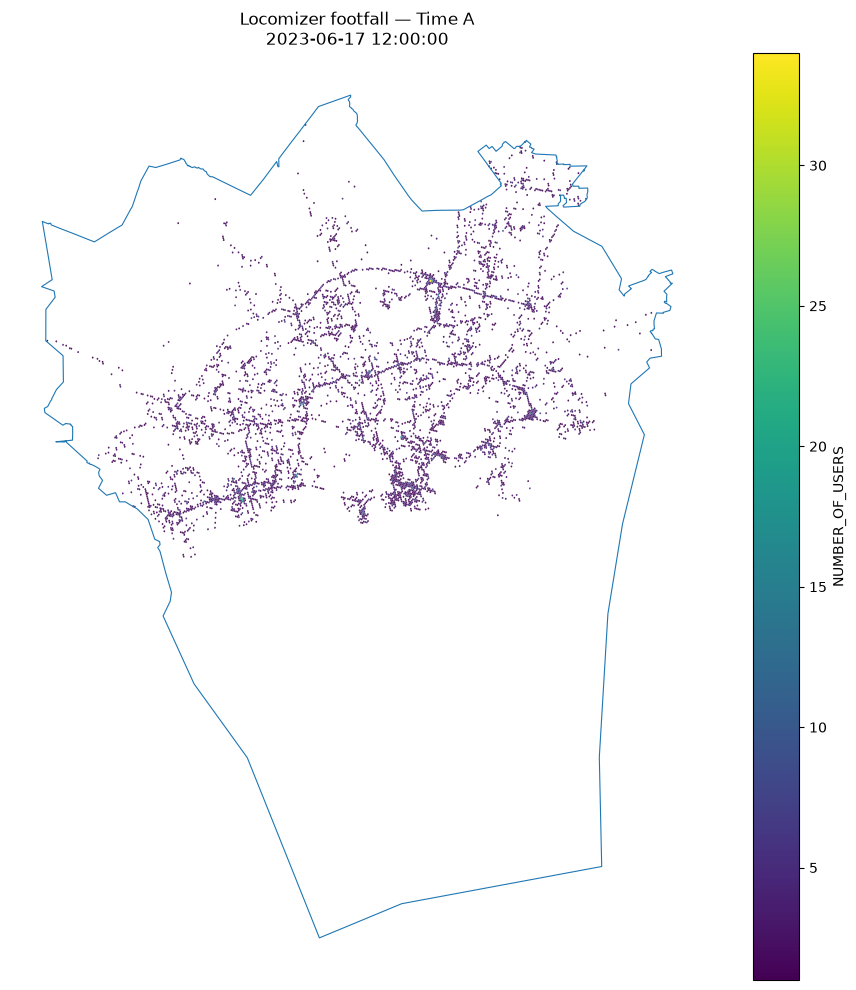

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

comparison_gdf.plot(
    ax=ax,
    column="footfall_A",
    legend=True,
    linewidth=0,
    alpha=0.9,
    legend_kwds={"label": "NUMBER_OF_USERS"},
)

ax.set_title(
    f"Locomizer footfall — Time A\n"
    f"{TIME_A}"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 16. Map footfall at Time B

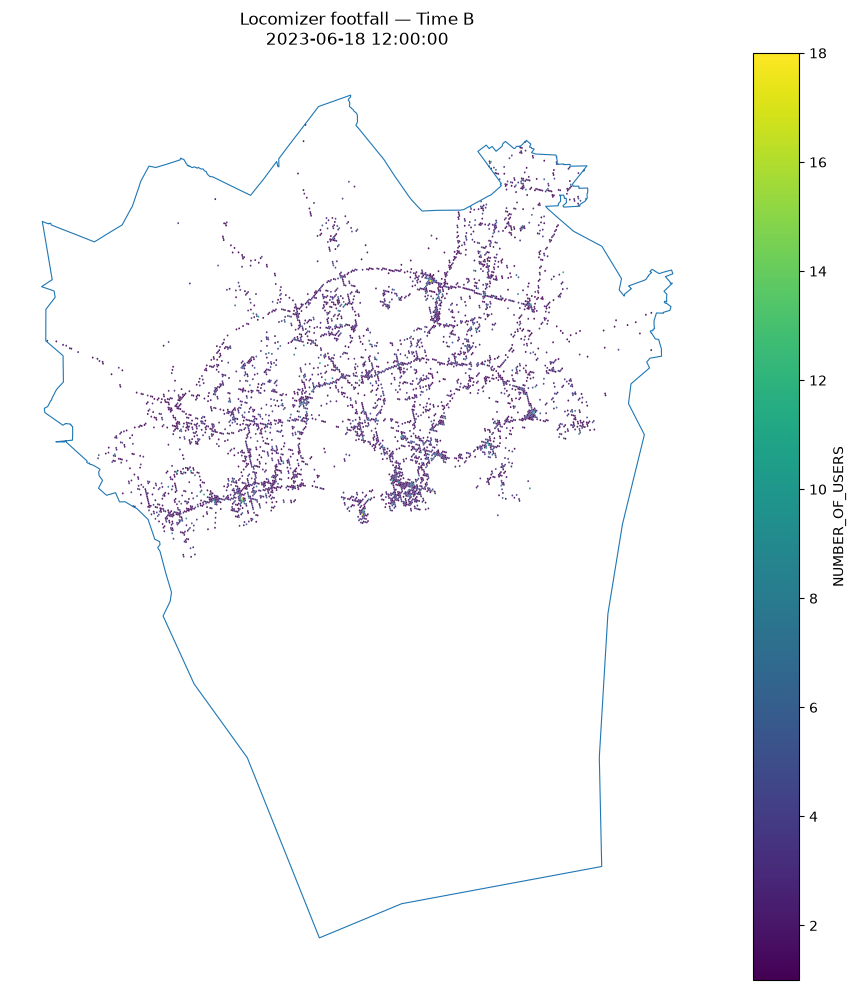

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

comparison_gdf.plot(
    ax=ax,
    column="footfall_B",
    legend=True,
    linewidth=0,
    alpha=0.9,
    legend_kwds={"label": "NUMBER_OF_USERS"},
)

ax.set_title(
    f"Locomizer footfall — Time B\n"
    f"{TIME_B}"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 17. Map H3 footfall percentage change

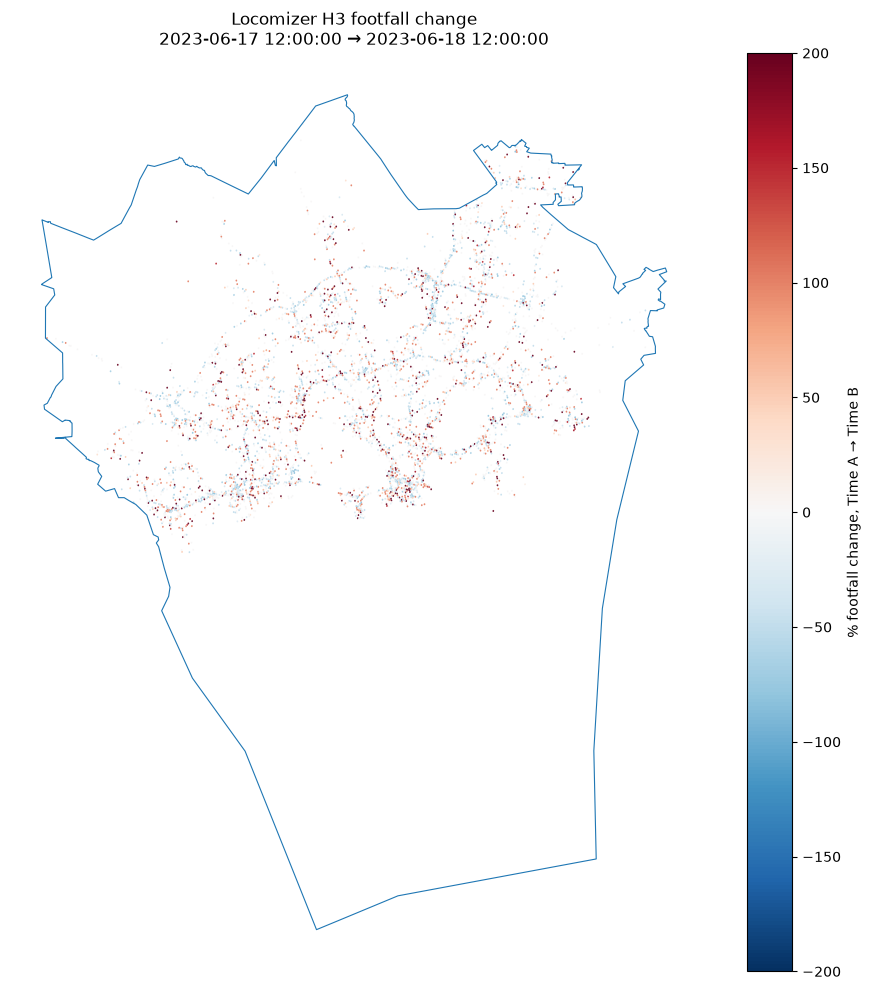

In [17]:
plot_change = comparison_gdf.dropna(
    subset=["pct_change_footfall"]
).copy()

limit = np.nanpercentile(
    np.abs(plot_change["pct_change_footfall"]),
    95,
)

if not np.isfinite(limit) or limit == 0:
    limit = 1

fig, ax = plt.subplots(figsize=(10, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

plot_change.plot(
    ax=ax,
    column="pct_change_footfall",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    legend=True,
    linewidth=0,
    alpha=0.9,
    legend_kwds={
        "label": "% footfall change, Time A → Time B"
    },
)

ax.set_title(
    "Locomizer H3 footfall change\n"
    f"{TIME_A} → {TIME_B}"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 18. Classify H3 footfall response using the regional PM₂.₅ direction

Because station PM₂.₅ is not spatially continuous, **the same regional PM₂.₅ direction is applied as contextual information to all H3 cells**.

This is intentionally different from claiming that every H3 cell had the same PM₂.₅ concentration.

The classification is:

- if regional PM₂.₅ increased and H3 footfall decreased → `possible avoidance`;
- if regional PM₂.₅ increased and H3 footfall was stable → `persistent activity`;
- if regional PM₂.₅ increased and H3 footfall increased → `increased activity despite poorer regional air`;
- if regional PM₂.₅ decreased → the H3 change is reported descriptively and **not interpreted as smoke avoidance**.

A ±5% footfall threshold defines “broadly stable”.


In [18]:
FOOTFALL_STABLE_THRESHOLD_PCT = 5.0

def classify_footfall_response(
    pct_change,
    regional_delta_pm25,
):
    if pd.isna(pct_change):
        return "missing footfall change"

    if regional_delta_pm25 > 0:
        if pct_change < -FOOTFALL_STABLE_THRESHOLD_PCT:
            return "possible avoidance"
        elif pct_change > FOOTFALL_STABLE_THRESHOLD_PCT:
            return "increased activity despite poorer regional air"
        else:
            return "persistent activity"

    elif regional_delta_pm25 < 0:
        if pct_change < -FOOTFALL_STABLE_THRESHOLD_PCT:
            return "footfall decreased while regional PM2.5 improved"
        elif pct_change > FOOTFALL_STABLE_THRESHOLD_PCT:
            return "footfall increased while regional PM2.5 improved"
        else:
            return "footfall stable while regional PM2.5 improved"

    else:
        if pct_change < -FOOTFALL_STABLE_THRESHOLD_PCT:
            return "footfall decreased; regional PM2.5 unchanged"
        elif pct_change > FOOTFALL_STABLE_THRESHOLD_PCT:
            return "footfall increased; regional PM2.5 unchanged"
        else:
            return "footfall stable; regional PM2.5 unchanged"

comparison_gdf["regional_pm25_A_median"] = pm25_A_median
comparison_gdf["regional_pm25_B_median"] = pm25_B_median
comparison_gdf["regional_delta_pm25_median"] = delta_pm25_median

comparison_gdf["response_class"] = [
    classify_footfall_response(
        pct_change,
        delta_pm25_median,
    )
    for pct_change in comparison_gdf["pct_change_footfall"]
]

display(
    comparison_gdf[
        [
            "CODE",
            "pct_change_footfall",
            "regional_delta_pm25_median",
            "response_class",
        ]
    ].head()
)

comparison_gdf["response_class"].value_counts()


,CODE,pct_change_footfall,regional_delta_pm25_median,response_class
0,8a08996d4c67fff,200.0,-2.85,footfall increased while regional PM2.5 improved
1,8a1126d3381ffff,0.0,-2.85,footfall stable while regional PM2.5 improved
2,8a1126d0e277fff,0.0,-2.85,footfall stable while regional PM2.5 improved
3,8a08996a8797fff,0.0,-2.85,footfall stable while regional PM2.5 improved
4,8a1126d2922ffff,200.0,-2.85,footfall increased while regional PM2.5 improved


response_class
footfall decreased while regional PM2.5 improved    1666
footfall stable while regional PM2.5 improved       1619
footfall increased while regional PM2.5 improved    1588
Name: count, dtype: int64

## 19. Map the contextual response classification

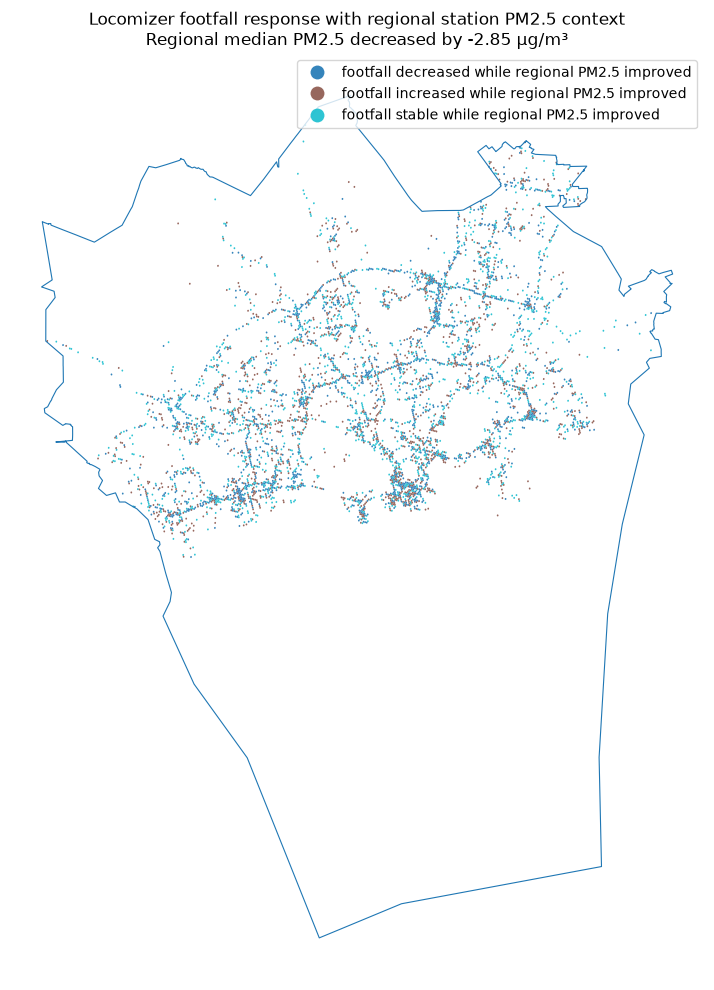

In [19]:
fig, ax = plt.subplots(figsize=(11, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

comparison_gdf.plot(
    ax=ax,
    column="response_class",
    categorical=True,
    legend=True,
    linewidth=0,
    alpha=0.9,
)

direction_text = (
    "increased"
    if delta_pm25_median > 0
    else "decreased"
    if delta_pm25_median < 0
    else "was unchanged"
)

ax.set_title(
    "Locomizer footfall response with regional station PM2.5 context\n"
    f"Regional median PM2.5 {direction_text} by "
    f"{delta_pm25_median:.2f} µg/m³"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


## 20. Regional footfall summary

The sums below are sums of cell-level `NUMBER_OF_USERS`.

They must not be described as unique people.


In [20]:
footfall_A_sum = comparison_gdf["footfall_A"].sum()
footfall_B_sum = comparison_gdf["footfall_B"].sum()

summary = pd.DataFrame(
    {
        "metric": [
            "cells compared",
            "summed cell users — Time A",
            "summed cell users — Time B",
            "change in summed cell users",
            "% change in summed cell users",
            "regional median PM2.5 — Time A",
            "regional median PM2.5 — Time B",
            "change in regional median PM2.5",
            "stations reporting — Time A",
            "stations reporting — Time B",
        ],
        "value": [
            len(comparison_gdf),
            footfall_A_sum,
            footfall_B_sum,
            footfall_B_sum - footfall_A_sum,
            (
                100
                * (footfall_B_sum - footfall_A_sum)
                / footfall_A_sum
                if footfall_A_sum > 0
                else np.nan
            ),
            pm25_A_median,
            pm25_B_median,
            delta_pm25_median,
            regional_lookup.loc[TIME_A, "n_stations"],
            regional_lookup.loc[TIME_B, "n_stations"],
        ],
    }
)

display(summary)


,metric,value
0,cells compared,4873.000000
1,summed cell users — Time A,11756.000000
2,summed cell users — Time B,11504.000000
3,change in summed cell users,-252.000000
4,% change in summed cell users,-2.143586
5,regional median PM2.5 — Time A,9.600000
6,regional median PM2.5 — Time B,6.750000
7,change in regional median PM2.5,-2.850000
8,stations reporting — Time A,10.000000
9,stations reporting — Time B,10.000000


## 21. Inspect stronger same-hour PM₂.₅ comparison candidates

Stage 00 creates a ranked table of same-clock-hour pairs.

This is useful because the 17 June vs 18 June 12:00 pair may not represent worsening air quality.

The strongest candidate can be copied into `TIME_A` and `TIME_B` at the top of this notebook.


In [21]:
if PM25_CANDIDATE_PAIRS_CSV.exists():
    candidate_pairs = pd.read_csv(
        PM25_CANDIDATE_PAIRS_CSV,
        parse_dates=["time_A", "time_B"],
    )

    display(candidate_pairs.head(20))
else:
    print(
        "Candidate-pairs file not found. "
        "Run Stage 00 to generate it."
    )


,hour,time_A,time_B,pm25_A_median,pm25_B_median,delta_pm25,abs_delta_pm25,n_stations_A,n_stations_B
0,7,2023-06-17 07:00:00,2023-06-18 07:00:00,16.65,8.10,-8.55,8.55,10,10
1,2,2023-06-18 02:00:00,2023-06-19 02:00:00,11.20,4.45,-6.75,6.75,10,10
2,0,2023-06-18 00:00:00,2023-06-19 00:00:00,11.05,4.50,-6.55,6.55,10,10
3,1,2023-06-18 01:00:00,2023-06-19 01:00:00,11.20,4.80,-6.40,6.40,10,10
4,8,2023-06-17 08:00:00,2023-06-18 08:00:00,14.45,8.05,-6.40,6.40,10,10
5,23,2023-06-17 23:00:00,2023-06-18 23:00:00,10.75,4.75,-6.00,6.00,10,10
6,3,2023-06-18 03:00:00,2023-06-19 03:00:00,10.40,4.55,-5.85,5.85,10,10
7,22,2023-06-17 22:00:00,2023-06-18 22:00:00,10.85,5.40,-5.45,5.45,10,10
8,21,2023-06-17 21:00:00,2023-06-18 21:00:00,10.90,5.70,-5.20,5.20,10,10
9,4,2023-06-18 04:00:00,2023-06-19 04:00:00,9.55,4.50,-5.05,5.05,10,10


## 22. Save outputs

In [22]:
comparison_csv = (
    OUTPUT_DIR
    / "locomizer_two_time_station_pm25_context.csv"
)

comparison_gpkg = (
    OUTPUT_DIR
    / "locomizer_two_time_station_pm25_context.gpkg"
)

station_change_csv = (
    OUTPUT_DIR
    / "pm25_station_two_time_change.csv"
)

regional_csv = (
    OUTPUT_DIR
    / "pm25_regional_two_time.csv"
)

summary_csv = (
    OUTPUT_DIR
    / "locomizer_pm25_two_time_summary.csv"
)

comparison_gdf.drop(
    columns="geometry"
).to_csv(
    comparison_csv,
    index=False,
)

comparison_gdf.to_file(
    comparison_gpkg,
    layer="h3_footfall_pm25_context",
    driver="GPKG",
)

station_wide.to_csv(
    station_change_csv,
    index=False,
)

regional_two_time.to_csv(
    regional_csv,
    index=False,
)

summary.to_csv(
    summary_csv,
    index=False,
)

print("Saved:")
for path in [
    comparison_csv,
    comparison_gpkg,
    station_change_csv,
    regional_csv,
    summary_csv,
]:
    print(" -", path)


Saved:
 - ../outputs/v3/05_locomizer_station_pm25/locomizer_two_time_station_pm25_context.csv
 - ../outputs/v3/05_locomizer_station_pm25/locomizer_two_time_station_pm25_context.gpkg
 - ../outputs/v3/05_locomizer_station_pm25/pm25_station_two_time_change.csv
 - ../outputs/v3/05_locomizer_station_pm25/pm25_regional_two_time.csv
 - ../outputs/v3/05_locomizer_station_pm25/locomizer_pm25_two_time_summary.csv


## 23. Interpretation and next step

This version now connects the actual historical station observations to Locomizer.

### What it supports

It can answer:

> Did HMA footfall change between two timestamps when the **regional monitoring-station PM₂.₅ context** changed?

### What it does not yet support

It cannot claim:

> This individual H3 cell had PM₂.₅ = X µg/m³.

For that, we would need either:

1. archived ENFUSER gridded PM₂.₅ for the exact hours, or
2. a separately justified spatial interpolation of station observations.

### Link to the CAFEIN workflow

CAFEIN route exposure should continue to use a spatial environmental surface. The station observations here are best treated as the **temporal validation / event-selection layer** until a spatial PM₂.₅ surface is available.
